<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd01/Class_Activation_Map_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p work/class_activation_map/data
!ln -s /content/data /content/work/class_activation_map/data

In [ ]:
!pip install opencv-python

라이브러리 불러오기

In [ ]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F
import PIL

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

print(torch.__version__)
print(np.__version__)
print(cv2.__version__)
print(PIL.__version__)

2.11.0+cu128
2.1.3
4.14.0
11.3.0


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


데이터셋 다운로드

In [ ]:
DOWNLOAD_URLS = {
    "lists.tar": "http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar",
    "annotation.tar": "http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar",
    "images.tar": "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar",
}

for filename, url in DOWNLOAD_URLS.items():

    if os.path.exists(filename):
        os.remove(filename)
    !wget -q --show-progress "{url}" -O "{filename}"

print("데이터 다운로드 완료!")


lists.tar           100%[===================>] 470.00K  2.37MB/s    in 0.2s    
annotation.tar      100%[===================>]  20.84M   964KB/s    in 16s     
images.tar          100%[===================>] 756.82M  1.44MB/s    in 12m 20s 
데이터 다운로드 완료!


파일 압축 풀기

In [ ]:
%cd /content

for filename in ["lists.tar", "images.tar", "annotation.tar"]:
    if not os.path.exists(filename) or os.path.getsize(filename) == 0:
        raise RuntimeError(f"{filename} 다운로드가 완료되지 않았습니다. 이전 셀을 다시 실행해 주세요.")

!tar -xf lists.tar -C /content/work/class_activation_map
!tar -xf images.tar -C /content/work/class_activation_map


/content


In [ ]:
check_dir = '/content/work/class_activation_map'

print(os.listdir(check_dir))


폴더 내 파일 목록:
['Images', 'test_list.mat', 'file_list.mat', 'data', 'train_list.mat']


데이터셋 재구성

In [ ]:
mat_dir = '/content/work/class_activation_map'
images_dir = '/content/work/class_activation_map/Images'

# .mat 파일 경로
train_mat_path = os.path.join(mat_dir, 'train_list.mat')
test_mat_path = os.path.join(mat_dir, 'test_list.mat')

# .mat 파일 로드
train_mat = sio.loadmat(train_mat_path)
test_mat = sio.loadmat(test_mat_path)

# 데이터 추출
train_file_list = train_mat['file_list']
train_labels = train_mat['labels'].squeeze()  # (N,)
test_file_list = test_mat['file_list']
test_labels = test_mat['labels'].squeeze()

base_dir = '/content/stanford_dogs'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

def process_mat_file(file_list_array, split_dir):
    """
    .mat 파일에서 로드한 file_list_array를 사용해,
    split_dir에 클래스별 폴더를 생성하고 이미지를 복사합니다.
    """
    num_files = file_list_array.shape[0]
    for idx in range(num_files):

        try:
            if file_list_array[idx].ndim > 0:
                file_path = file_list_array[idx][0].item()
            else:
                file_path = file_list_array[idx].item()
        except (AttributeError, IndexError):
            file_path = file_list_array[idx].item()

        # 혹시 bytes 타입이면 문자열로 디코딩
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        # 클래스 이름 추출
        class_folder = file_path.split('/')[0]

        # 대상 클래스 폴더 생성
        dest_folder = os.path.join(split_dir, class_folder)
        os.makedirs(dest_folder, exist_ok=True)

        # 원본 이미지 및 대상 이미지 경로
        src_path = os.path.join(images_dir, file_path)
        dest_path = os.path.join(dest_folder, os.path.basename(file_path))

        # 파일 존재 여부 확인 후 복사
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f"File not found: {src_path}")

print("Processing train set...")
process_mat_file(train_file_list, train_dir)
print("Processing test set...")
process_mat_file(test_file_list, test_dir)

print("Dataset reorganization complete.")


Processing train set...
Processing test set...
Dataset reorganization complete.


In [ ]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
            except Exception:
                pass

        return image, label, bbox

이미지 전처리(transform)를 정의하고,

train/valid Dataset과 DataLoader를 생성

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')

annotation_dir = '/content/work/class_activation_map/Annotation'

train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [ ]:
def visualize(sample):
    img_tensor, label, bbox = sample

    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

train_dataset의 첫 번째 샘플 확인

Label index: 0
Class name: n02085620-Chihuahua


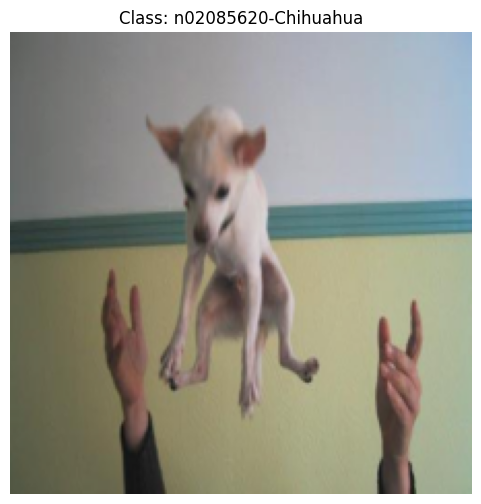

In [ ]:
train_sample = train_dataset[0]

visualize(train_sample)

valid_dataset의 첫 번째 샘플 확인

Label index: 0
Class name: n02085620-Chihuahua


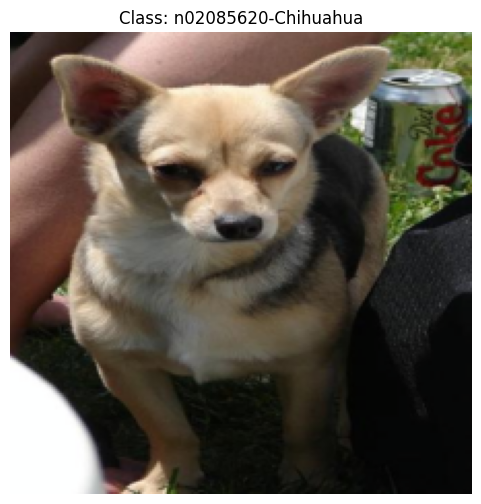

In [ ]:
test_sample = valid_dataset[0]

visualize(test_sample)

## 위치정보

In [ ]:
!tar -xf /content/annotation.tar -C /content/work/class_activation_map

In [ ]:
annotation_path = '/content/work/class_activation_map/Annotation/n02085620-Chihuahua/n02085620_10074'

if not os.path.exists(annotation_path) and os.path.exists(annotation_path + '.xml'):
    annotation_path += '.xml'

tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")


annotation: 
	
folder: 02085620
filename: n02085620_10074
source: 
		
database: ImageNet database
size: 
		
width: 333
height: 500
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 25
ymin: 10
xmax: 276
ymax: 498


## CAM 모델만들기

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s]


모델 확인

In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## CAM 모델 학습하기

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):

    history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")


        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        valid_loss = running_loss / len(valid_loader)
        valid_acc = correct / total
        print(f"Validation - Loss: {valid_loss:.4f}, Accuracy: {valid_acc*100:.2f}%")

        # 수렴 여부를 그래프로 확인할 수 있도록 epoch별 기록을 저장
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

    return history


In [ ]:
%%time

history = train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=5)



Epoch 1/5 시작
  Step 50 - Loss: 4.1496
  Step 100 - Loss: 3.8826
  Step 150 - Loss: 3.9467
  Step 200 - Loss: 3.6066
  Step 250 - Loss: 3.0498
  Step 300 - Loss: 3.1606
  Step 350 - Loss: 3.2131
  Step 400 - Loss: 3.9452
  Step 450 - Loss: 3.1242
  Step 500 - Loss: 3.2053
  Step 550 - Loss: 3.8154
  Step 600 - Loss: 2.6523
  Step 650 - Loss: 2.6925
  Step 700 - Loss: 2.5478
  Step 750 - Loss: 2.6740
  Step 800 - Loss: 3.4152
  Step 850 - Loss: 2.4744
  Step 900 - Loss: 3.0487
  Step 950 - Loss: 2.2572
  Step 1000 - Loss: 3.0951
Train - Loss: 3.2354, Accuracy: 22.23%
Validation - Loss: 2.6019, Accuracy: 33.16%

Epoch 2/5 시작
  Step 50 - Loss: 2.8270
  Step 100 - Loss: 2.4670
  Step 150 - Loss: 1.4415
  Step 200 - Loss: 2.2353
  Step 250 - Loss: 2.7491
  Step 300 - Loss: 1.9442
  Step 350 - Loss: 1.8366
  Step 400 - Loss: 2.1708
  Step 450 - Loss: 1.9839
  Step 500 - Loss: 2.6717
  Step 550 - Loss: 2.1855
  Step 600 - Loss: 2.0509
  Step 650 - Loss: 2.3146
  Step 700 - Loss: 2.1455
  Step

epoch별 Loss/Accuracy 그래프

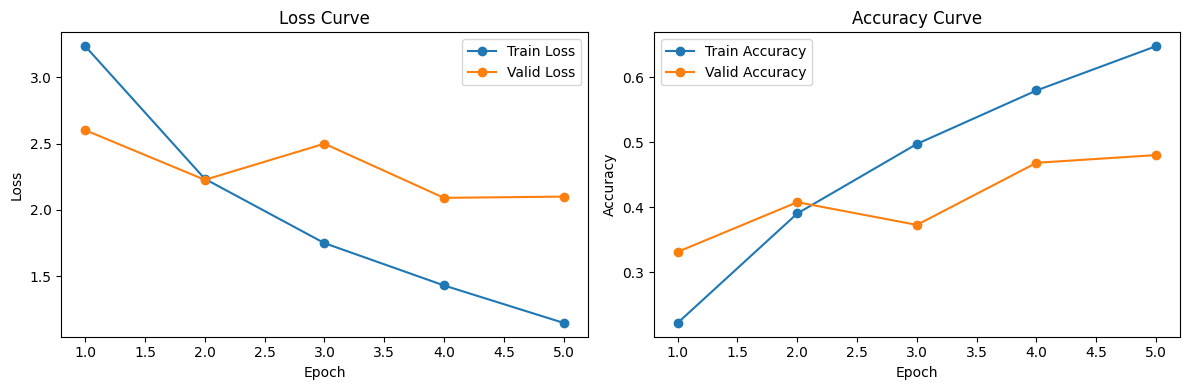

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], marker='o', label='Train Loss')
axes[0].plot(epochs_range, history["valid_loss"], marker='o', label='Valid Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker='o', label='Train Accuracy')
axes[1].plot(epochs_range, history["valid_acc"], marker='o', label='Valid Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
cam_model_path = '/content/work/class_activation_map/cam_model.pt'

torch.save(model, cam_model_path)

## CAM 생성

In [ ]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

In [ ]:
image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [ ]:
model = torch.load(cam_model_path, weights_only=False)

In [ ]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [ ]:
cam = generate_cam(model, sample_image)

In [ ]:
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

생성한 CAM 시각화

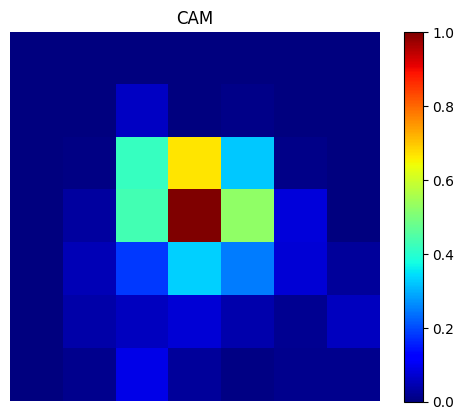

In [ ]:
visualize_cam(cam)

In [ ]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

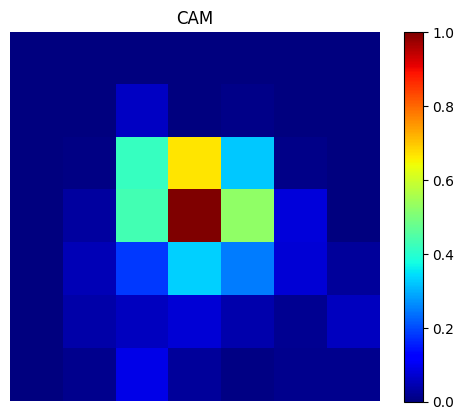

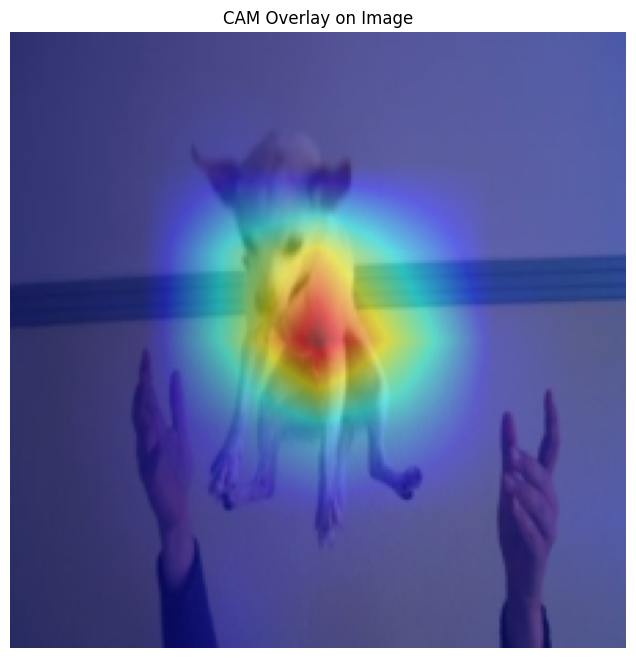

In [ ]:
# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img)

Grad-CAM

In [ ]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장 (full backward hook 사용)
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

layer4 : Grad-CAM을 생성하고, 단독 시각화 및 원본 이미지 오버레이 시각화

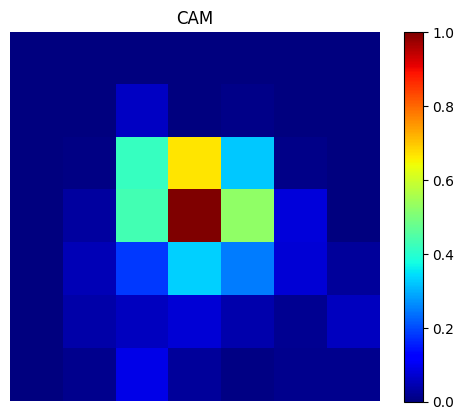

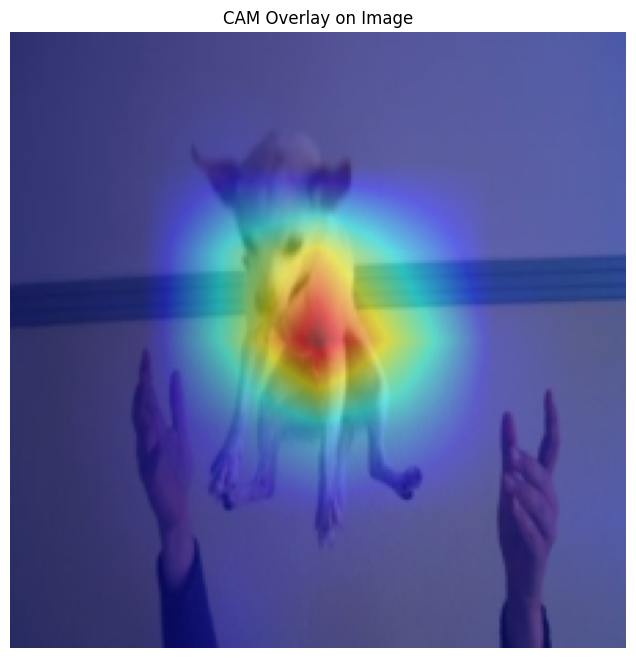

In [ ]:
# layer4 사용
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

layer1 : Grad-CAM을 생성하고 동일하게 시각화

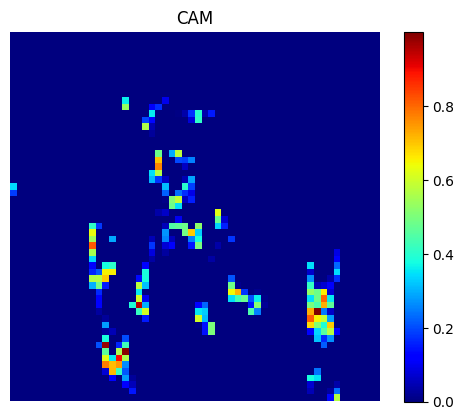

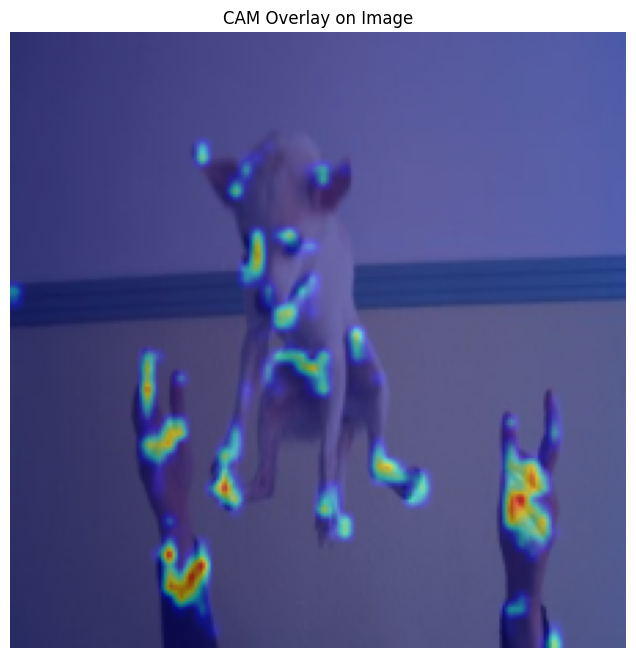

In [ ]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer1")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

layer2 : Grad-CAM을 생성하고 동일하게 시각화

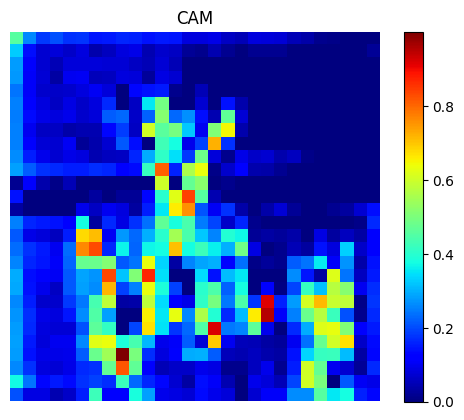

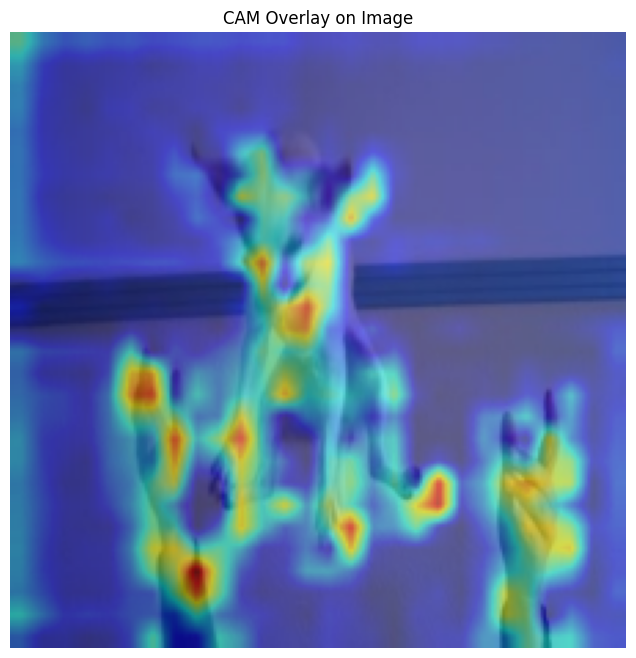

In [ ]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer2")

visualize_cam(grad_cam)

orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

layer3 : Grad-CAM을 생성하고 동일하게 시각화

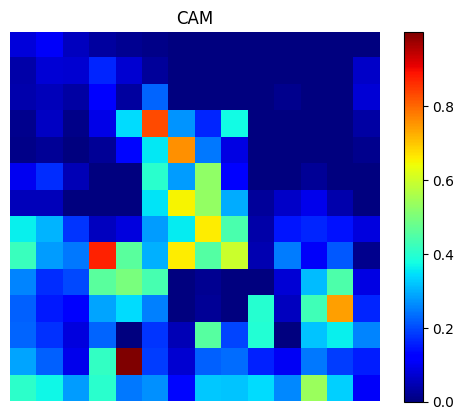

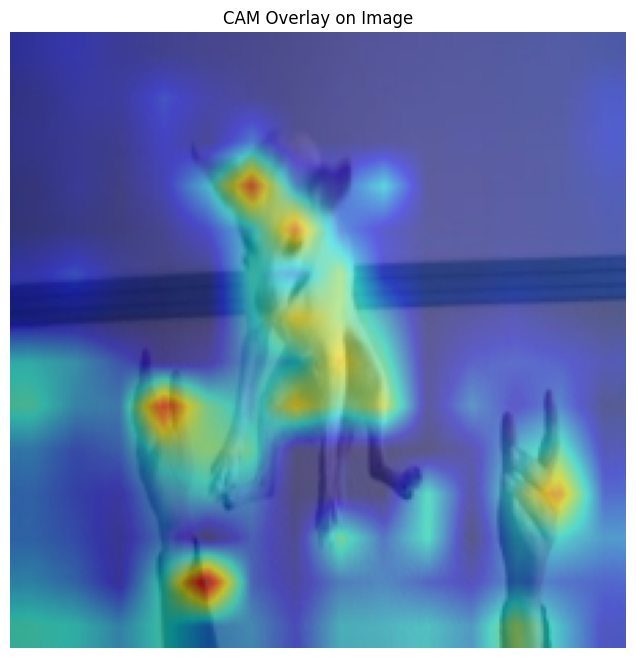

In [ ]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer3")

visualize_cam(grad_cam)

orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

## Detection with CAM

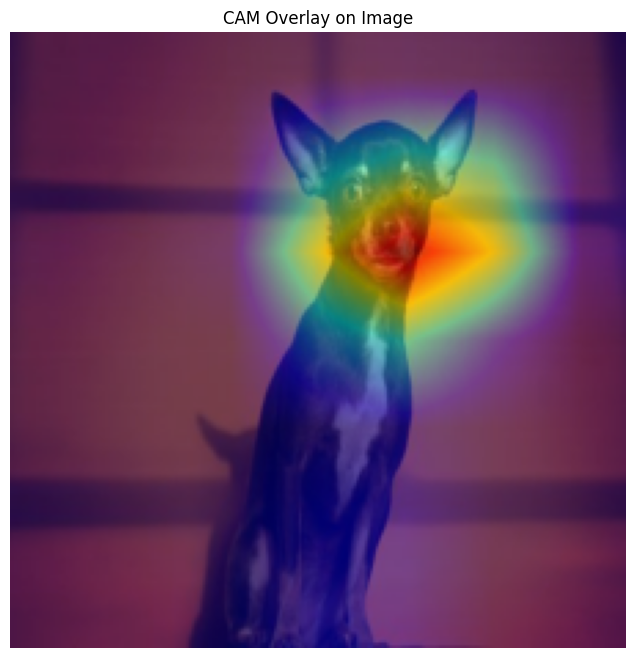

In [ ]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

visualize_cam_on_image(grad_cam, orig_img)

In [ ]:
def get_bbox(cam, threshold=0.01):
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [ ]:
cam_resized = cv2.resize(grad_cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.5)

print(bbox)

(np.int64(108), np.int64(51), np.int64(182), np.int64(105))


In [ ]:
cam = generate_cam(model, sample_image)
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
cam_bbox = get_bbox(cam_resized, threshold=0.5)

print("CAM bbox:", cam_bbox)
print("Grad-CAM bbox:", bbox)


CAM bbox: (np.int64(108), np.int64(51), np.int64(182), np.int64(105))
Grad-CAM bbox: (np.int64(108), np.int64(51), np.int64(182), np.int64(105))


In [ ]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

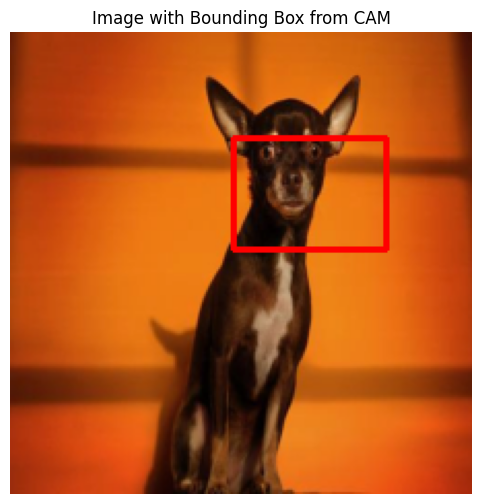

In [ ]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from CAM")
plt.axis("off")
plt.show()

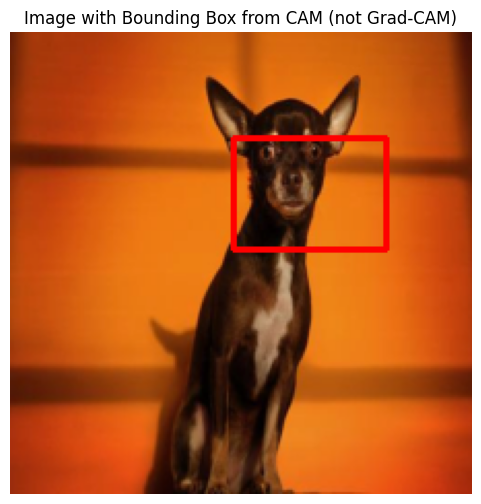

In [ ]:
img_bbox_cam = visualize_bbox_on_image(orig_img, cam_bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox_cam)
plt.title("Image with Bounding Box from CAM (not Grad-CAM)")
plt.axis("off")
plt.show()


## ground_bbox

정답 바운딩 박스 값 확인

In [ ]:
ground_bbox

[78.848, 19.333333333333332, 169.792, 222.0]

In [ ]:
def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [ ]:
get_iou(bbox, ground_bbox)

np.float64(0.17478637946650322)

In [ ]:
iou_cam = get_iou(cam_bbox, ground_bbox)
iou_grad_cam = get_iou(bbox, ground_bbox)

print(f"CAM IoU:      {iou_cam:.4f}")
print(f"Grad-CAM IoU: {iou_grad_cam:.4f}")


CAM IoU:      0.1748
Grad-CAM IoU: 0.1748


CAM과 Grad-CAM의 object localization 성능 비교분석

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


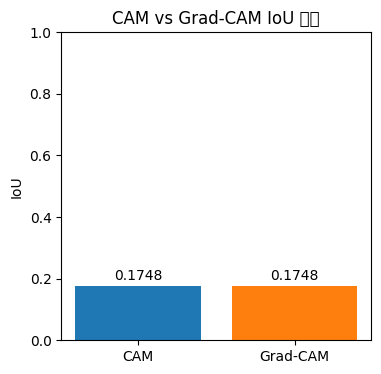

이번 샘플에서는 CAM과 Grad-CAM의 IoU가 동일했습니다.


In [ ]:
plt.figure(figsize=(4, 4))
plt.bar(["CAM", "Grad-CAM"], [iou_cam, iou_grad_cam], color=["tab:blue", "tab:orange"])
plt.ylabel("IoU")
plt.ylim(0, 1)
plt.title("CAM vs Grad-CAM IoU 비교")
for x, v in enumerate([iou_cam, iou_grad_cam]):
    plt.text(x, v + 0.02, f"{v:.4f}", ha="center")
plt.show()

if iou_grad_cam > iou_cam:
    better, diff = "Grad-CAM", iou_grad_cam - iou_cam
elif iou_cam > iou_grad_cam:
    better, diff = "CAM", iou_cam - iou_grad_cam
else:
    better, diff = None, 0.0

if better:
    print(f"이번 샘플에서는 {better}의 IoU가 {diff:.4f} 더 높아, "
          f"객체 위치(object localization)를 더 정확하게 잡아냈습니다.")
else:
    print("이번 샘플에서는 CAM과 Grad-CAM의 IoU가 동일했습니다.")


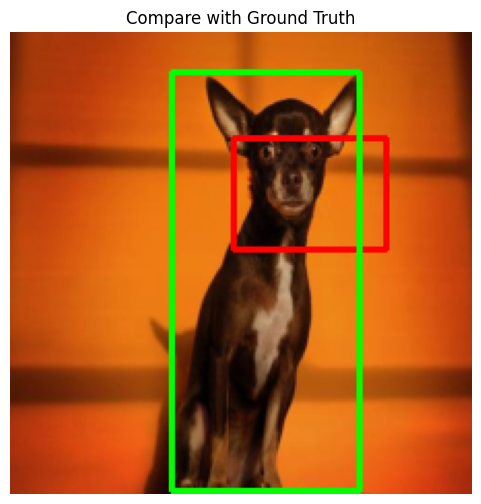

In [ ]:
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

일반 CAM으로 구한 바운딩 박스(빨강)와 정답 바운딩 박스(초록)를 같은 이미지 위에 겹쳐서 비교 시각화

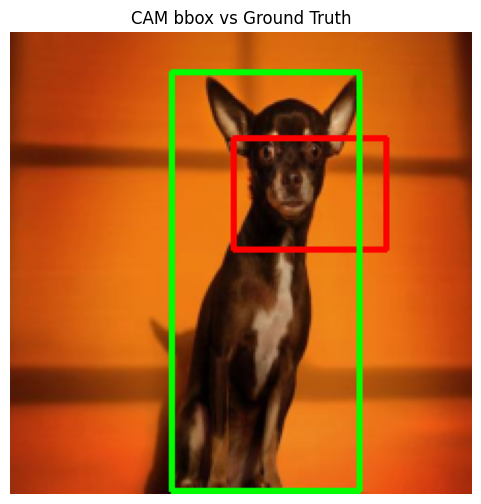

In [ ]:
img_bbox_cam_vs_gt = visualize_both_bbox_on_image(orig_img, cam_bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox_cam_vs_gt)
plt.title("CAM bbox vs Ground Truth")
plt.axis("off")
plt.show()
